In [12]:
%matplotlib inline
from plot_stock_changes import create_diverging_prediction_chart
from spark_init import initialize_spark
from config_loader import load_config
from pandas_util import convert_to_yfinance_format
from finance_util import calculate_technical_indicators
from pyspark.sql import SparkSession
from pyspark.sql import DataFrame as SparkDataFrame
from pyspark.sql.functions import col,min,dayofweek,current_date,date_sub,to_date,abs,lit,desc
from pyspark.sql.functions import sum as spark_sum,max as spark_max, min as spark_min
from pyspark.sql.types import IntegerType
from datetime import datetime, timedelta, date
import os

In [13]:
date_threshold = datetime(datetime.today().year - 1, 12, 1)
print(f"date_threshold : {date_threshold}")
# Create directory if it doesn't exist
today = date.today()
end_date = today.strftime("%Y-%m-%d")
print(f"end_date : {end_date}")
symbol = 'IDT'

date_threshold : 2024-12-01 00:00:00
end_date : 2025-02-25


In [14]:
tablename = "stocksinfp"
prediction_table = "stocks_prediction"
# Load configuration details
try:
    url, driver, username, password = load_config()
    print(f"URL: {url}, Driver: {driver}, Username: {username}, Table: {tablename}")
except Exception as e:
    print(f"Error loading config: {e}")
spark = initialize_spark("Stock Market Data Analysis Functions")

URL: jdbc:mysql://localhost/stocksdb, Driver: com.mysql.cj.jdbc.Driver, Username: quizadmin, Table: stocksinfp


In [15]:
stock_df = spark.read.format("jdbc").options(url=url, driver=driver, user=username, password=password, dbtable=tablename).load()
prediction_df = spark.read.format("jdbc").options(url=url, driver=driver, user=username, password=password, dbtable=prediction_table).load()
# prediction_df.printSchema()
# stock_df.printSchema()

In [16]:
#stock_df = stock_df.filter(col("symbol") == symbol)
#prediction_df = prediction_df.filter(col("symbol") == symbol)
# Ensure Date column is in DateType
prediction_df = prediction_df.withColumn("Date", to_date(col("Date")))
stock_df = stock_df.withColumn("Date", to_date(col("Date")))
# Get minimum start date
min_start_date = prediction_df.agg(min(col("Date"))).collect()[0][0]

# Filter stock_df
stock_df = stock_df.filter(col("Date") >= lit(min_start_date))

#stock_df.show(5, truncate=False)

In [17]:
# Convert string columns to appropriate types in predictions DataFrame
pred_df = prediction_df \
    .withColumn('Date', to_date('Date')) \
    .withColumn('Predicted_Price', col('Predicted_Price').cast('double')) \
    .withColumnRenamed('Low', 'pred_Low') \
    .withColumn('pred_Low', col('pred_Low').cast('double')) \
    .withColumnRenamed('High', 'pred_High') \
    .withColumn('pred_High', col('pred_High').cast('double'))

# Convert string columns to appropriate types in historical DataFrame
hist_df = stock_df \
    .withColumn('Open', col('Open').cast('double')) \
    .withColumn('High', col('High').cast('double')) \
    .withColumn('Low', col('Low').cast('double')) \
    .withColumn('Close', col('Close').cast('double')) \
    .withColumn('Adj Close', col('Adj Close').cast('double')) \
    .withColumn('Volume', col('Volume').cast('double'))

# Standardize symbol column names
pred_df = pred_df.withColumnRenamed('Symbol', 'symbol')

# Join the DataFrames
combined_df = pred_df.join(
    hist_df,
    on=['Date', 'symbol'],
    how='inner'
)
combined_df.show(5, truncate=False)
df = combined_df

+----------+------+---------------+--------+---------+------------------+------------------+------------------+------------------+------------------+----------+--------------------+
|Date      |symbol|Predicted_Price|pred_Low|pred_High|Open              |High              |Low               |Close             |Adj Close         |Volume    |price_change        |
+----------+------+---------------+--------+---------+------------------+------------------+------------------+------------------+------------------+----------+--------------------+
|2025-02-24|AI    |29.08          |28.02   |30.13    |28.110000610351562|28.25             |26.34000015258789 |26.8799991607666  |26.8799991607666  |5398196.0 |-1.6200008392333984 |
|2025-02-24|WDAY  |261.57         |256.83  |266.3    |255.17999267578125|263.54998779296875|251.02999877929688|261.80999755859375|261.80999755859375|3649140.0 |5.41998291015625    |
|2025-02-25|PLTR  |103.4          |97.56   |109.23   |90.6500015258789  |91.69999694824219

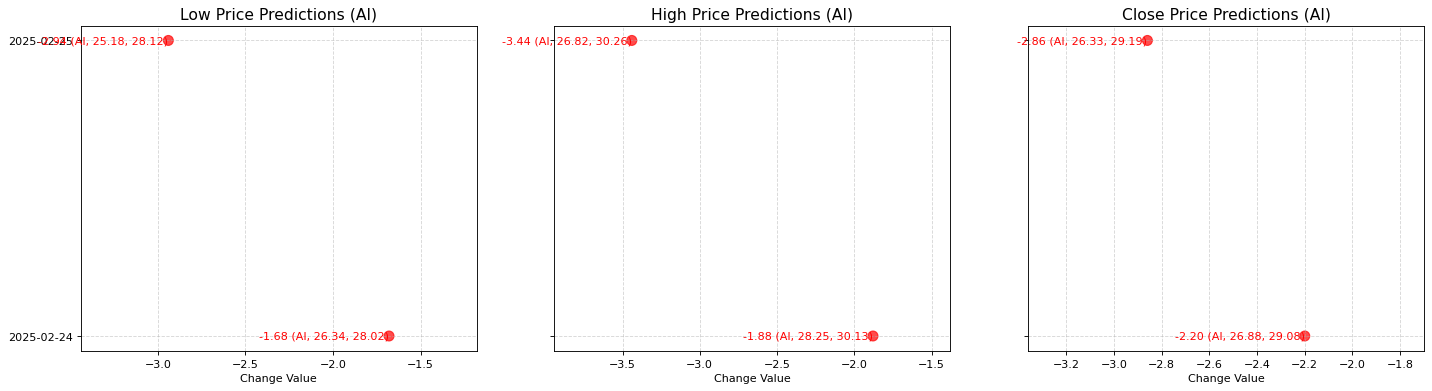

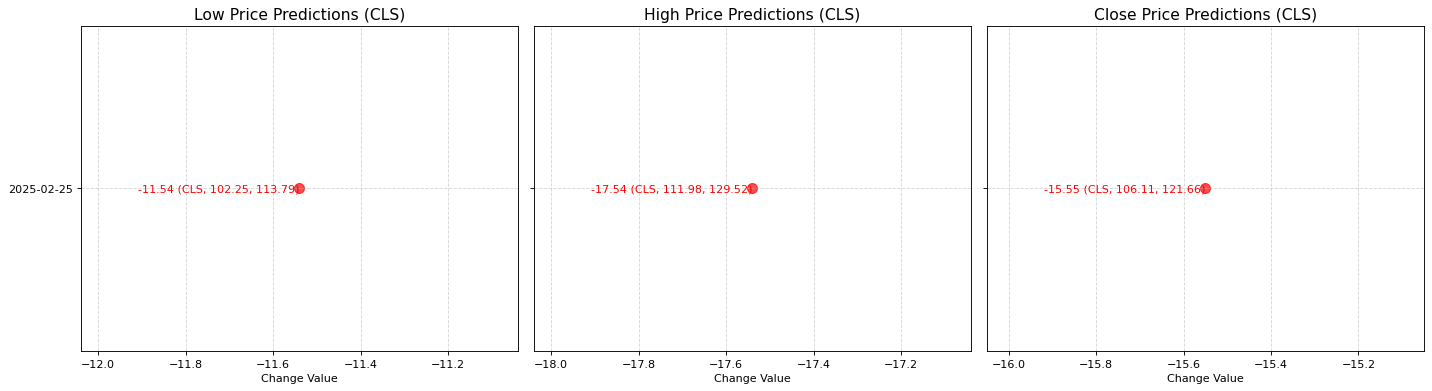

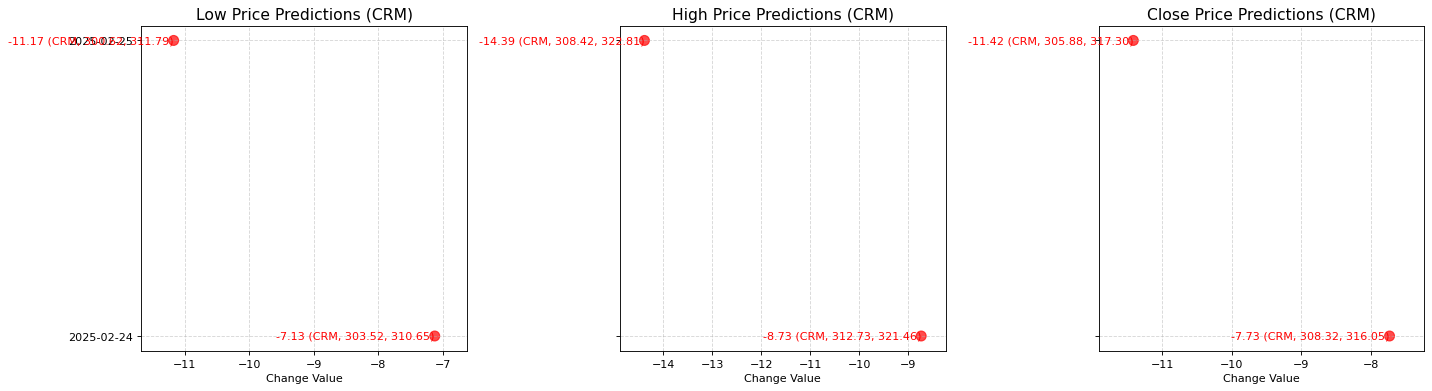

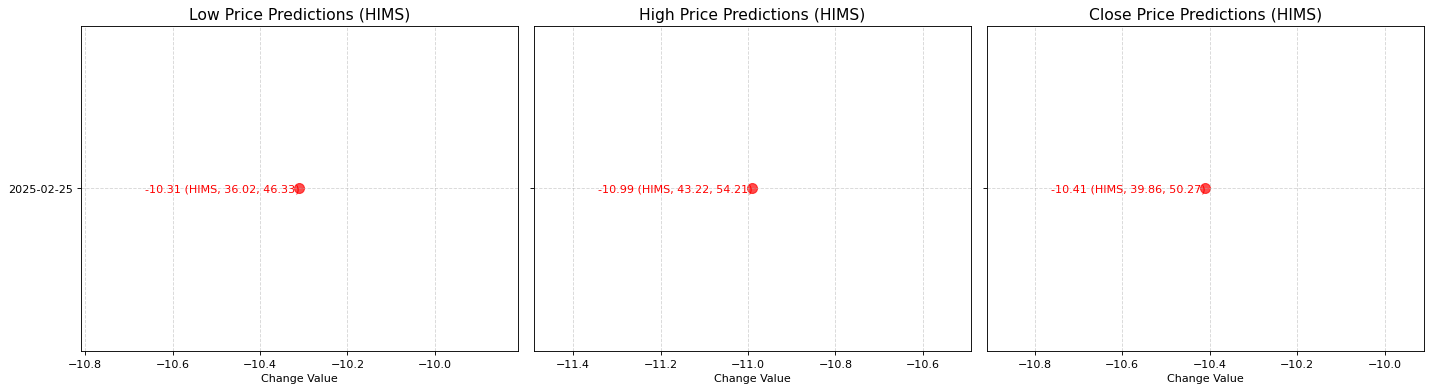

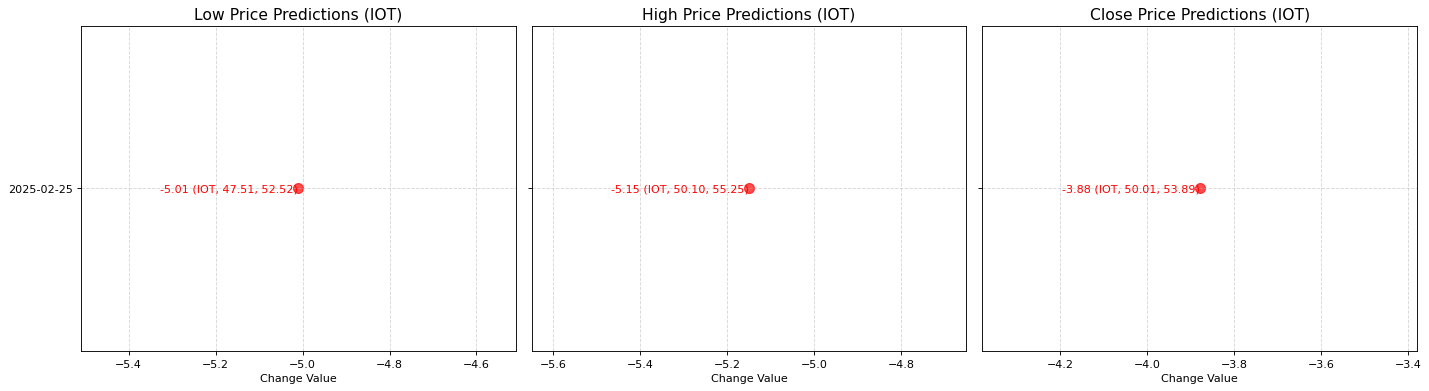

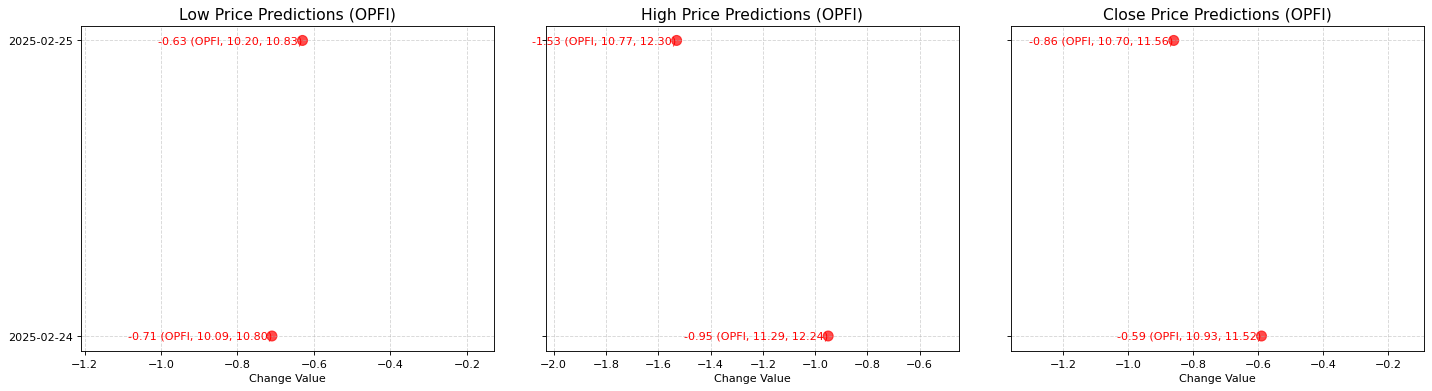

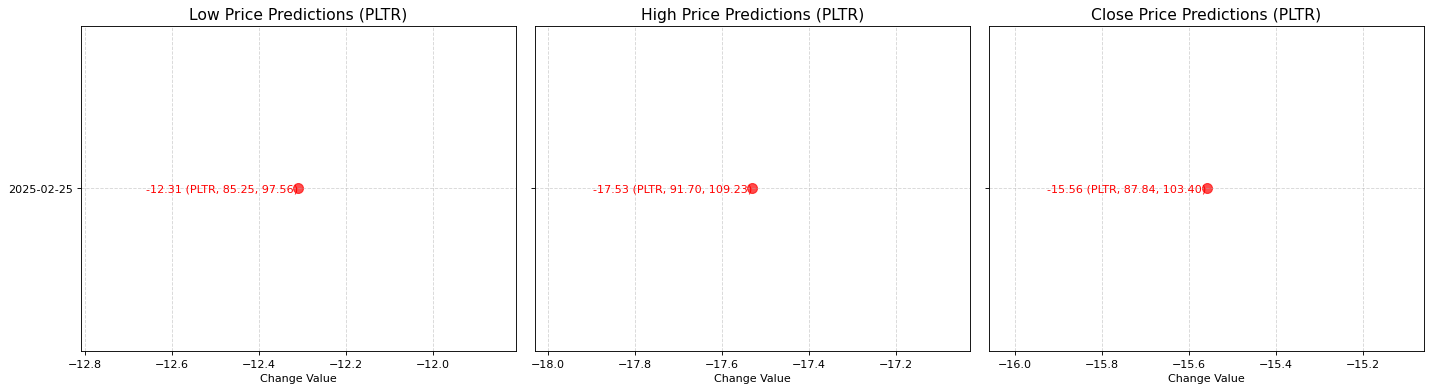

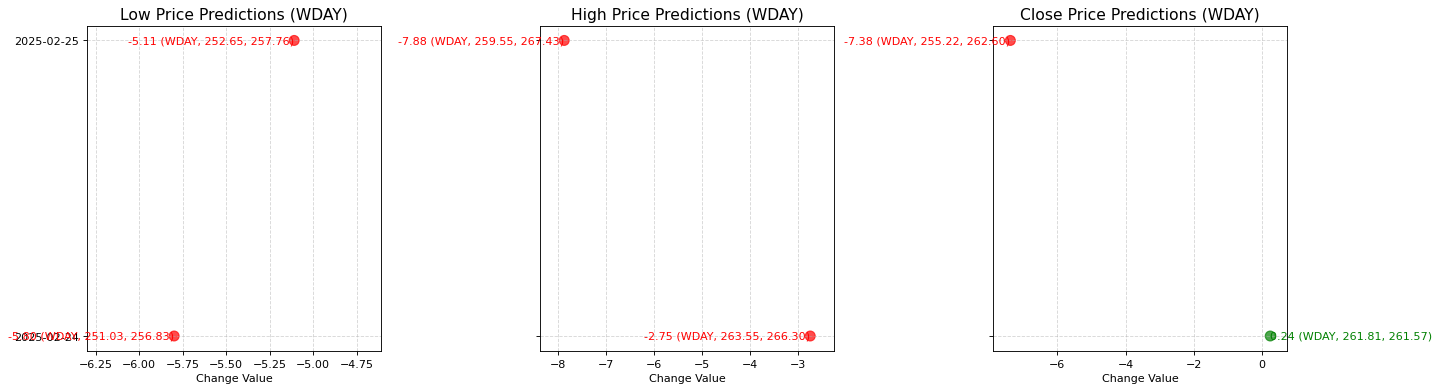

In [18]:
# Convert Spark DataFrame to Pandas
pandas_df = df.toPandas().copy()
# Call the function to generate plots
create_diverging_prediction_chart(pandas_df)

In [19]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

def process_stock_data(combined_df):
    """
    Process and join stock prediction and historical data DataFrames.
    
    Parameters:
    combined_df: DataFrame with stock data including predictions
    
    Returns:
    DataFrame with calculated metrics
    """
    # Define Windows
    window_5d = Window.partitionBy('symbol').orderBy(F.col('Date').cast('date')).rowsBetween(-4, 0)
    window_30d = Window.partitionBy('symbol').orderBy(F.col('Date').cast('date')).rowsBetween(-29, 0)
    
    # Calculate additional metrics
    combined_df = combined_df \
        .withColumn('prediction_accuracy', 
                    F.when(F.col('Close') != 0, 
                           (F.abs(F.col('Predicted_Price') - F.col('Close')) / F.col('Close') * 100)).otherwise(None)) \
        .withColumn('price_volatility', 
                    F.when(F.col('Open') != 0, 
                           ((F.col('High') - F.col('Low')) / F.col('Open') * 100)).otherwise(None)) \
        .withColumn('prediction_within_range', 
                    F.col('Predicted_Price').between(F.col('Low'), F.col('High')).cast('int')) \
        .withColumn('ma_5d_close', F.avg('Close').over(window_5d)) \
        .withColumn('ma_30d_close', F.avg('Close').over(window_30d)) \
        .withColumn('ma_5d_volume', F.avg('Volume').over(window_5d)) \
        .withColumn('ma_5d_prediction_accuracy', F.avg('prediction_accuracy').over(window_5d)) \
        .withColumn('pred_range_width', F.col('pred_High') - F.col('pred_Low')) \
        .withColumn('actual_range_width', F.col('High') - F.col('Low')) \
        .withColumn('range_accuracy', 
                    F.when(F.col('actual_range_width') != 0, 
                           (F.abs(F.col('pred_range_width') - F.col('actual_range_width')) / F.col('actual_range_width') * 100)).otherwise(None))
    
    return combined_df


In [20]:
def generate_summary_stats(combined_df):
    """
    Generate summary statistics for the combined data.
    
    Parameters:
    combined_df: Processed DataFrame from process_stock_data
    
    Returns:
    DataFrame with summary statistics by symbol
    """
    summary_stats = combined_df.groupBy('symbol').agg(
        F.avg('prediction_accuracy').alias('avg_prediction_accuracy'),
        F.stddev('prediction_accuracy').alias('std_prediction_accuracy'),
        F.avg('price_volatility').alias('avg_volatility'),
        F.avg('range_accuracy').alias('avg_range_accuracy'),
        F.sum('prediction_within_range').alias('predictions_within_range'),
        F.count('*').alias('total_predictions'),
        F.min(F.col('Date').cast('date')).alias('start_date'),
        F.max(F.col('Date').cast('date')).alias('end_date')
    )
    
    # Calculate success rate
    summary_stats = summary_stats.withColumn(
        'prediction_success_rate',
        (F.col('predictions_within_range') / F.col('total_predictions') * 100).alias('prediction_success_rate')
    )
    summary_stats = summary_stats.fillna({'std_prediction_accuracy': 0})
    return summary_stats

In [21]:
# Process the data
processed_df = process_stock_data(combined_df)

# Generate summary statistics
summary_df = generate_summary_stats(processed_df)

# Show results
#processed_df.show()
summary_df.show()
# Check schema
# processed_df.printSchema()


+------+-----------------------+-----------------------+------------------+------------------+------------------------+-----------------+----------+----------+-----------------------+
|symbol|avg_prediction_accuracy|std_prediction_accuracy|    avg_volatility|avg_range_accuracy|predictions_within_range|total_predictions|start_date|  end_date|prediction_success_rate|
+------+-----------------------+-----------------------+------------------+------------------+------------------------+-----------------+----------+----------+-----------------------+
|   IOT|      7.758451926994275|                    0.0| 5.176894294987809|5.4053991955259315|                       0|                1|2025-02-25|2025-02-25|                    0.0|
|  OPFI|      6.717684675908883|     1.8663382428428303|  8.03547868995489| 88.94723125238613|                       0|                2|2025-02-24|2025-02-25|                    0.0|
|    AI|      9.523330977919015|     1.8933544781843845| 6.502250515551442|20.47

In [22]:
import matplotlib.pyplot as plt

summary_pdf = summary_df.toPandas().copy()
